In [1]:
import torch
import numpy as np
import scipy.io
import h5py
import torch.nn as nn

import operator
from functools import reduce
from functools import partial
torch.manual_seed(1069)
#from utilities3 import *

#################################################
#
# Utilities
#
#################################################
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# reading data
class MatReader(object):
    def __init__(self, file_path, to_torch=True, to_cuda=False, to_float=True):
        super(MatReader, self).__init__()

        self.to_torch = to_torch
        self.to_cuda = to_cuda
        self.to_float = to_float

        self.file_path = file_path

        self.data = None
        self.old_mat = None
        self._load_file()

    def _load_file(self):
        try:
            self.data = scipy.io.loadmat(self.file_path)
            self.old_mat = True
        except:
            self.data = h5py.File(self.file_path)
            self.old_mat = False

    def load_file(self, file_path):
        self.file_path = file_path
        self._load_file()

    def read_field(self, field):
        x = self.data[field]

        if not self.old_mat:
            x = x[()]
            x = np.transpose(x, axes=range(len(x.shape) - 1, -1, -1))

        if self.to_float:
            x = x.astype(np.float32)

        if self.to_torch:
            x = torch.from_numpy(x)

            if self.to_cuda:
                x = x.cuda()

        return x

    def set_cuda(self, to_cuda):
        self.to_cuda = to_cuda

    def set_torch(self, to_torch):
        self.to_torch = to_torch

    def set_float(self, to_float):
        self.to_float = to_float

# normalization, pointwise gaussian
class UnitGaussianNormalizer(object):
    def __init__(self, x, eps=0.00001):
        super(UnitGaussianNormalizer, self).__init__()

        # x could be in shape of ntrain*n or ntrain*T*n or ntrain*n*T
        self.mean = torch.mean(x, 0)
        self.std = torch.std(x, 0)
        self.eps = eps

    def encode(self, x):
        x = (x - self.mean) / (self.std + self.eps)
        return x

    def decode(self, x, sample_idx=None):
        if sample_idx is None:
            std = self.std + self.eps # n
            mean = self.mean
        else:
            if len(self.mean.shape) == len(sample_idx[0].shape):
                std = self.std[sample_idx] + self.eps  # batch*n
                mean = self.mean[sample_idx]
            if len(self.mean.shape) > len(sample_idx[0].shape):
                std = self.std[:,sample_idx]+ self.eps # T*batch*n
                mean = self.mean[:,sample_idx]

        # x is in shape of batch*n or T*batch*n
        print("this is x",  x.shape)
        print("this is std",std.shape)
        print("this is mean",mean.shape)
        x = (x * std) + mean
        return x

    def cuda(self):
        self.mean = self.mean.cuda()
        self.std = self.std.cuda()

    def cpu(self):
        self.mean = self.mean.cpu()
        self.std = self.std.cpu()

# normalization, Gaussian
class GaussianNormalizer(object):
    def __init__(self, x, eps=0.00001):
        super(GaussianNormalizer, self).__init__()

        self.mean = torch.mean(x)
        self.std = torch.std(x)
        self.eps = eps

    def encode(self, x):
        x = (x - self.mean) / (self.std + self.eps)
        return x

    def decode(self, x, sample_idx=None):
        x = (x * (self.std + self.eps)) + self.mean
        return x

    def cuda(self):
        self.mean = self.mean.cuda()
        self.std = self.std.cuda()

    def cpu(self):
        self.mean = self.mean.cpu()
        self.std = self.std.cpu()


# normalization, scaling by range
class RangeNormalizer(object):
    def __init__(self, x, low=0.0, high=1.0):
        super(RangeNormalizer, self).__init__()
        mymin = torch.min(x, 0)[0].view(-1)
        mymax = torch.max(x, 0)[0].view(-1)

        self.a = (high - low)/(mymax - mymin)
        self.b = -self.a*mymax + high

    def encode(self, x):
        s = x.size()
        x = x.view(s[0], -1)
        x = self.a*x + self.b
        x = x.view(s)
        return x

    def decode(self, x):
        s = x.size()
        x = x.view(s[0], -1)
        x = (x - self.b)/self.a
        x = x.view(s)
        return x

#loss function with rel/abs Lp loss
class LpLoss(object):
    def __init__(self, d=2, p=2, size_average=True, reduction=True):
        super(LpLoss, self).__init__()

        #Dimension and Lp-norm type are postive
        assert d > 0 and p > 0

        self.d = d
        self.p = p
        self.reduction = reduction
        self.size_average = size_average

    def abs(self, x, y):
        num_examples = x.size()[0]

        #Assume uniform mesh
        h = 1.0 / (x.size()[1] - 1.0)

        all_norms = (h**(self.d/self.p))*torch.norm(x.view(num_examples,-1) - y.view(num_examples,-1), self.p, 1)

        if self.reduction:
            if self.size_average:
                return torch.mean(all_norms)
            else:
                return torch.sum(all_norms)

        return all_norms

    def rel(self, x, y):
        num_examples = x.size()[0]

        diff_norms = torch.norm(x.reshape(num_examples,-1) - y.reshape(num_examples,-1), self.p, 1)
        y_norms = torch.norm(y.reshape(num_examples,-1), self.p, 1)

        if self.reduction:
            if self.size_average:
                return torch.mean(diff_norms/y_norms)
            else:
                return torch.sum(diff_norms/y_norms)

        return diff_norms/y_norms

    def __call__(self, x, y):
        return self.rel(x, y)

# Sobolev norm (HS norm)
# where we also compare the numerical derivatives between the output and target
class HsLoss(object):
    def __init__(self, d=2, p=2, k=1, a=None, group=False, size_average=True, reduction=True):
        super(HsLoss, self).__init__()

        #Dimension and Lp-norm type are postive
        assert d > 0 and p > 0

        self.d = d
        self.p = p
        self.k = k
        self.balanced = group
        self.reduction = reduction
        self.size_average = size_average

        if a == None:
            a = [1,] * k
        self.a = a

    def rel(self, x, y):
        num_examples = x.size()[0]
        diff_norms = torch.norm(x.reshape(num_examples,-1) - y.reshape(num_examples,-1), self.p, 1)
        y_norms = torch.norm(y.reshape(num_examples,-1), self.p, 1)
        if self.reduction:
            if self.size_average:
                return torch.mean(diff_norms/y_norms)
            else:
                return torch.sum(diff_norms/y_norms)
        return diff_norms/y_norms

    def __call__(self, x, y, a=None):
        nx = x.size()[1]
        ny = x.size()[2]
        k = self.k
        balanced = self.balanced
        a = self.a
        x = x.view(x.shape[0], nx, ny, -1)
        y = y.view(y.shape[0], nx, ny, -1)

        k_x = torch.cat((torch.arange(start=0, end=nx//2, step=1),torch.arange(start=-nx//2, end=0, step=1)), 0).reshape(nx,1).repeat(1,ny)
        k_y = torch.cat((torch.arange(start=0, end=ny//2, step=1),torch.arange(start=-ny//2, end=0, step=1)), 0).reshape(1,ny).repeat(nx,1)
        k_x = torch.abs(k_x).reshape(1,nx,ny,1).to(x.device)
        k_y = torch.abs(k_y).reshape(1,nx,ny,1).to(x.device)

        x = torch.fft.fftn(x, dim=[1, 2])
        y = torch.fft.fftn(y, dim=[1, 2])

        if balanced==False:
            weight = 1
            if k >= 1:
                weight += a[0]**2 * (k_x**2 + k_y**2)
            if k >= 2:
                weight += a[1]**2 * (k_x**4 + 2*k_x**2*k_y**2 + k_y**4)
            weight = torch.sqrt(weight)
            loss = self.rel(x*weight, y*weight)
        else:
            loss = self.rel(x, y)
            if k >= 1:
                weight = a[0] * torch.sqrt(k_x**2 + k_y**2)
                loss += self.rel(x*weight, y*weight)
            if k >= 2:
                weight = a[1] * torch.sqrt(k_x**4 + 2*k_x**2*k_y**2 + k_y**4)
                loss += self.rel(x*weight, y*weight)
            loss = loss / (k+1)

        return loss

# A simple feedforward neural network
class DenseNet(torch.nn.Module):
    def __init__(self, layers, nonlinearity, out_nonlinearity=None, normalize=False):
        super(DenseNet, self).__init__()

        self.n_layers = len(layers) - 1

        assert self.n_layers >= 1

        self.layers = nn.ModuleList()

        for j in range(self.n_layers):
            self.layers.append(nn.Linear(layers[j], layers[j+1]))

            if j != self.n_layers - 1:
                if normalize:
                    self.layers.append(nn.BatchNorm1d(layers[j+1]))

                self.layers.append(nonlinearity())

        if out_nonlinearity is not None:
            self.layers.append(out_nonlinearity())

    def forward(self, x):
        for _, l in enumerate(self.layers):
            x = l(x)

        return x


# print the number of parameters
def count_params(model):
    c = 0
    for p in list(model.parameters()):
        c += reduce(operator.mul, list(p.size()))
    return c


# Using Fourier Nueral Operators for learning the elastic wave equation
## GEOPH 699 Final Project.
### Tianze Zhang
#### Dec. 6 2021
---



In [2]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from timeit import default_timer

In [3]:
x = torch.rand(10, 1, 5, 5)
y = x.repeat(1, 1000, 1, 1)
print(y.shape)

torch.Size([10, 1000, 5, 5])


In [4]:
class U_net(nn.Module):
    def __init__(self, input_channels, output_channels, kernel_size, dropout_rate):
        super(U_net, self).__init__()
        self.input_channels = input_channels
        self.conv1 = self.conv(input_channels, output_channels, kernel_size=kernel_size, stride=2, dropout_rate = dropout_rate)
        self.conv2 = self.conv(input_channels, output_channels, kernel_size=kernel_size, stride=2, dropout_rate = dropout_rate)
        self.conv2_1 = self.conv(input_channels, output_channels, kernel_size=kernel_size, stride=1, dropout_rate = dropout_rate)
        self.conv3 = self.conv(input_channels, output_channels, kernel_size=kernel_size, stride=2, dropout_rate = dropout_rate)
        self.conv3_1 = self.conv(input_channels, output_channels, kernel_size=kernel_size, stride=1, dropout_rate = dropout_rate)
        
        self.deconv2 = self.deconv(input_channels, output_channels)
        self.deconv1 = self.deconv(input_channels*2, output_channels)
        self.deconv0 = self.deconv(input_channels*2, output_channels)
    
        self.output_layer = self.output(input_channels*2, output_channels, 
                                         kernel_size=kernel_size, stride=1, dropout_rate = dropout_rate)


    def forward(self, x):
        out_conv1 = self.conv1(x)
        out_conv2 = self.conv2_1(self.conv2(out_conv1))
        out_conv3 = self.conv3_1(self.conv3(out_conv2))
        out_deconv2 = self.deconv2(out_conv3)
        concat2 = torch.cat((out_conv2, out_deconv2), 1)
        out_deconv1 = self.deconv1(concat2)
        concat1 = torch.cat((out_conv1, out_deconv1), 1)
        out_deconv0 = self.deconv0(concat1)
        concat0 = torch.cat((x, out_deconv0), 1)
        out = self.output_layer(concat0)

        return out

    def conv(self, in_planes, output_channels, kernel_size, stride, dropout_rate):
        return nn.Sequential(
            nn.Conv3d(in_planes, output_channels, kernel_size=kernel_size,
                      stride=stride, padding=(kernel_size - 1) // 2, bias = False),
            nn.BatchNorm3d(output_channels),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(dropout_rate)
        )

    def deconv(self, input_channels, output_channels):
        return nn.Sequential(
            nn.ConvTranspose3d(input_channels, output_channels, kernel_size=4,
                               stride=2, padding=1),
            nn.LeakyReLU(0.1, inplace=True)
        )

    def output(self, input_channels, output_channels, kernel_size, stride, dropout_rate):
        return nn.Conv3d(input_channels, output_channels, kernel_size=kernel_size,
                         stride=stride, padding=(kernel_size - 1) // 2)

In [5]:
class SpectralConv3d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2, modes3):
        super(SpectralConv3d, self).__init__()

        """
        3D Fourier layer. It does FFT, linear transform, and Inverse FFT.    
        """

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1 #Number of Fourier modes to multiply, at most floor(N/2) + 1
        self.modes2 = modes2
        self.modes3 = modes3

        self.scale = (1 / (in_channels * out_channels*1600))
        self.weights1 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, self.modes3, dtype=torch.cfloat))
        self.weights3 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, self.modes3, dtype=torch.cfloat))
        self.weights5 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, self.modes3, dtype=torch.cfloat))

    # Complex multiplication
    def compl_mul3d(self, input, weights):
        # (batch, in_channel, x,y,t ), (in_channel, out_channel, x,y,t) -> (batch, out_channel, x,y,t)
        return torch.einsum("bixyz,ioxyz->boxyz", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        #Compute Fourier coeffcients up to factor of e^(- something constant)
        x_ft = torch.fft.rfftn(x, dim=[-3,-2,-1])

        # Multiply relevant Fourier modes
        out_ft = torch.zeros(batchsize, self.out_channels, x.size(-3), x.size(-2), x.size(-1)//2 + 1, dtype=torch.cfloat, device=x.device)
        out_ft[:, :, :self.modes1, :self.modes2, :self.modes3]   = self.compl_mul3d(x_ft[:, :, :self.modes1,  :self.modes2,  :self.modes3], self.weights1)
        out_ft[:, :, :self.modes1, -self.modes2:, :self.modes3]  = self.compl_mul3d(x_ft[:, :, :self.modes1,  -self.modes2:, :self.modes3], self.weights3)#
        out_ft[:, :, :self.modes1,  :self.modes2, -self.modes3:] = self.compl_mul3d(x_ft[:, :, :self.modes1,  :self.modes2, -self.modes3:], self.weights5)#

        #Return to physical space
        x = torch.fft.irfftn(out_ft, s=(x.size(-3), x.size(-2), x.size(-1)))
        return x

class FNO3d(nn.Module):
    def __init__(self, modes1, modes2, modes3, width):
        super(FNO3d, self).__init__()

        """
        The overall network. It contains 4 layers of the Fourier layer.
        1. Lift the input to the desire channel dimension by self.fc0 .
        2. 4 layers of the integral operators u' = (W + K)(u).
            W defined by self.w; K defined by self.conv .
        3. Project from the channel space to the output space by self.fc1 and self.fc2 .
        
        input: the solution of the first 10 timesteps + 3 locations (u(1, x, y), ..., u(10, x, y),  x, y, t). It's a constant function in time, except for the last index.
        input shape: (batchsize, x=64, y=64, t=40, c=13)
        output: the solution of the next 40 timesteps
        output shape: (batchsize, x=64, y=64, t=40, c=1)
        """

        self.modes1 = modes1
        self.modes2 = modes2
        self.modes3 = modes3
        self.width = width
        self.padding = 6 # pad the domain if input is non-periodic
        self.fc0 = nn.Linear(7, self.width)
        # input channel is 12: the solution of the first 10 timesteps + 3 locations (u(1, x, y), ..., u(10, x, y),  x, y, t)

        self.conv0 = SpectralConv3d(self.width, self.width, self.modes1, self.modes2, self.modes3)
        self.conv1 = SpectralConv3d(self.width, self.width, self.modes1, self.modes2, self.modes3)
        self.conv2 = SpectralConv3d(self.width, self.width, self.modes1, self.modes2, self.modes3)
        self.conv3 = SpectralConv3d(self.width, self.width, self.modes1, self.modes2, self.modes3)
        self.conv4 = SpectralConv3d(self.width, self.width, self.modes1, self.modes2, self.modes3)
        #self.conv5 = SpectralConv3d(self.width, self.width, self.modes1, self.modes2, self.modes3)
        #self.conv6 = SpectralConv3d(self.width, self.width, self.modes1, self.modes2, self.modes3)
        #self.conv7 = SpectralConv3d(self.width, self.width, self.modes1, self.modes2, self.modes3)


        self.unet0 = U_net(self.width, self.width, 3, 0)
        self.unet1 = U_net(self.width, self.width, 3, 0)
        self.unet2 = U_net(self.width, self.width, 3, 0)
        self.unet3 = U_net(self.width, self.width, 3, 0)
        self.unet4 = U_net(self.width, self.width, 3, 0)
        #self.unet5 = U_net(self.width, self.width, 3, 0)
        #self.unet6 = U_net(self.width, self.width, 3, 0)
        #self.unet7 = U_net(self.width, self.width, 3, 0)

        self.w0 = nn.Conv3d(self.width, self.width, 1)
        self.w1 = nn.Conv3d(self.width, self.width, 1)
        self.w2 = nn.Conv3d(self.width, self.width, 1)
        self.w3 = nn.Conv3d(self.width, self.width, 1)
        self.w4 = nn.Conv3d(self.width, self.width, 1)
        #self.w5 = nn.Conv3d(self.width, self.width, 1)
        #self.w6 = nn.Conv3d(self.width, self.width, 1)
        #self.w7 = nn.Conv3d(self.width, self.width, 1)

        
        self.bn0 = torch.nn.BatchNorm3d(self.width)
        self.bn1 = torch.nn.BatchNorm3d(self.width)
        self.bn2 = torch.nn.BatchNorm3d(self.width)
        #self.bn3 = torch.nn.BatchNorm3d(self.width)
        #self.bn4 = torch.nn.BatchNorm3d(self.width)

        self.fc1 = nn.Linear(self.width, 256)
        self.fc2 = nn.Linear(256, 1)

    def forward(self, C1, W1, dx, dy, dt):
        grid = self.get_grid(dx, dy, dt, C1.shape, C1.device)
        #print("this is the shape of C1", C1.shape)
        #print("this is the shape of W1", W1.shape)
        #print("this is the shape of grid", grid.shape)
        
        x = torch.cat((C1, W1, grid), dim=-1)
        x = self.fc0(x)
        x = x.permute(0, 4, 1, 2, 3)
        #x = F.pad(x, [0,self.padding]) # pad the domain if input is non-periodic

        x1 = self.conv0(x)
        x2 = self.w0(x)
        x3 = self.unet0(x)
        x = (x1 + x2 + x3)
        x = F.gelu(x)

        x1 = self.conv1(x)
        x2 = self.w1(x)
        x3 = self.unet1(x)
        x = (x1 + x2 + x3)
        x = F.gelu(x)

        x1 = self.conv2(x)
        x2 = self.w2(x)
        x3 = self.unet2(x)
        x = (x1 + x2 + x3)
        x = F.gelu(x)
        #x = x[..., :-self.padding]
        x = x.permute(0, 2, 3, 4, 1) # pad the domain if input is non-periodic
        x = self.fc1(x)
        #x = F.gelu(x)
        x = self.fc2(x)
        return x

    def get_grid(self, dx, dy, dz, shape, device):
        batchsize, size_x, size_y, size_z = shape[0], shape[1], shape[2], shape[3]
        gridx = torch.tensor(np.linspace(0, dx*size_x, size_x), dtype=torch.float)
        gridx = gridx.reshape(1, size_x, 1, 1, 1).repeat([batchsize, 1, size_y, size_z, 1])
        gridy = torch.tensor(np.linspace(0, dy*size_y, size_y), dtype=torch.float)
        gridy = gridy.reshape(1, 1, size_y, 1, 1).repeat([batchsize, size_x, 1, size_z, 1])
        gridz = torch.tensor(np.linspace(0, dz*size_z, size_z), dtype=torch.float)
        gridz = gridz.reshape(1, 1, 1, size_z, 1).repeat([batchsize, size_x, size_y, 1, 1])
        return torch.cat((gridx, gridy, gridz), dim=-1).to(device)

3.  **Data preperation**
    * I prepared 300 vp velocity models. Vs models and density models are obtained through scaling the vp models
    * The ground truth wave fields are calculated according to the finite difference method. (1 order in time 4 order in space).
    

In [6]:
N_models = 1000
DATA_PATH = './CFNO_Data_set_low_freq_test/'
vx_x_train1 = torch.load(DATA_PATH+'/vx_x_data_set_training_2024_0916_test1.pt')
vx_x_train2 = torch.load(DATA_PATH+'/vx_x_data_set_training_2024_0916_test2.pt')
vx_x_train = torch.cat((vx_x_train1,vx_x_train2), dim=0)

del vx_x_train1, vx_x_train2
print("this is the shape of the vx_x_train original size",vx_x_train.shape)

vp_train1  = torch.load(DATA_PATH+'/vp_data_set_training_2024_0916_test1.pt')
vp_train2  = torch.load(DATA_PATH+'/vp_data_set_training_2024_0916_test2.pt')
vp_train = torch.cat((vp_train1, vp_train2), dim=0)
del vp_train1, vp_train2

vs_train1  = torch.load(DATA_PATH+'/vs_data_set_training_2024_0916_test1.pt')
vs_train2  = torch.load(DATA_PATH+'/vs_data_set_training_2024_0916_test2.pt')
vs_train =  torch.cat((vs_train1, vs_train2), dim=0)
del vs_train1, vs_train2

rho_train1  = torch.load(DATA_PATH+'/rho_data_set_training_2024_0916_test1.pt')
rho_train2  = torch.load(DATA_PATH+'/rho_data_set_training_2024_0916_test1.pt')
rho_train =  torch.cat((rho_train1, rho_train2), dim=0)
del rho_train1, rho_train2


this is the shape of the vx_x_train original size torch.Size([2000, 300, 64, 64])


In [7]:
vp_train = torch.as_tensor(vp_train,dtype=torch.float32)
vs_train = torch.as_tensor(vs_train,dtype=torch.float32)
rho_train = torch.as_tensor(rho_train,dtype=torch.float32)

num_model_samples, num_channels, nz, nx = vp_train.shape
vp_train_reshape = torch.unsqueeze((vp_train.permute(0, 2, 3,1))/1000, dim=-1)
vs_train_reshape = torch.unsqueeze((vs_train.permute(0, 2, 3,1))/1000, dim=-1)
rho_train_reshape =torch.unsqueeze((rho_train.permute(0, 2, 3,1))/1000, dim=-1)

Models_train = torch.cat((vp_train_reshape, vs_train_reshape, rho_train_reshape), dim=-1)
print(Models_train.shape)

torch.Size([2000, 64, 64, 1, 3])


In [8]:
vx_x_train = torch.as_tensor(vx_x_train,dtype=torch.float32)
num_model_samples, num_time_step, nz, nx = vx_x_train.shape
vx_x_train_reshape = torch.unsqueeze(torch.nn.functional.normalize(vx_x_train.permute(0, 2, 3, 1)), dim=-1)

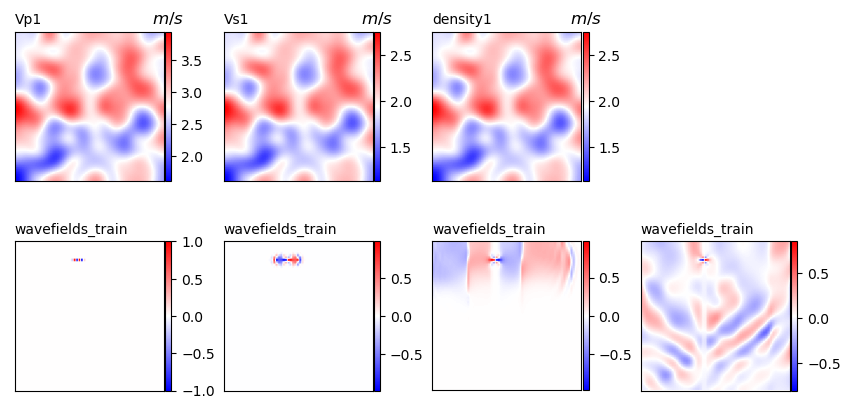

In [9]:
from Plotting_class import add_colorbar
model_index0 = 60
color = 'bwr'
fontsize_plt = 10

fig = plt.figure(figsize=(10, 5))
gs = fig.add_gridspec(2, 4)
ax = fig.add_subplot(gs[0, 0])
im = ax.imshow(Models_train[model_index0,:,:, :, 0].squeeze().detach(), cmap=color)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Vp1", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%", ctitle='$m/s$')

ax = fig.add_subplot(gs[0, 1])
im = ax.imshow(Models_train[model_index0,:,:, :, 1].squeeze().detach(), cmap=color)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Vs1", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%", ctitle='$m/s$')


ax = fig.add_subplot(gs[0, 2])
im = ax.imshow(Models_train[model_index0,:,:, :, 2].squeeze().detach(), cmap=color)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("density1", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%", ctitle='$m/s$')
##########################################################################################
##########################################################################################
##########################################################################################

ax = fig.add_subplot(gs[1, 0])
im = ax.imshow(vx_x_train_reshape[model_index0,:,:,0,:].squeeze().detach(), cmap=color)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("wavefields_train", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%")

ax = fig.add_subplot(gs[1, 1])
im = ax.imshow(vx_x_train_reshape[model_index0,:,:,10,:].squeeze().detach(), cmap=color)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("wavefields_train", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%")

ax = fig.add_subplot(gs[1, 2])
im = ax.imshow(vx_x_train_reshape[model_index0,:,:,100,:].squeeze().detach(), cmap=color)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("wavefields_train", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%")

ax = fig.add_subplot(gs[1, 3])
im = ax.imshow(vx_x_train_reshape[model_index0,:,:,-1,:].squeeze().detach(), cmap=color)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("wavefields_train", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%")

plt.subplots_adjust(left=0.125,
                    bottom=0.1,
                    right=0.9,
                    top=0.9,
                    wspace=0.4,
                    hspace=0.1)

In [10]:
# Preparing the training and testing wavefields
ntrain = int(Models_train.shape[0]*0.9)
ntest  = int(Models_train.shape[0]*0.1)
sub = 1
t_max=201
input_time = 1
time_prediction_number = t_max - input_time

Models_train_sub  = Models_train[:ntrain,::sub,::sub,:]
Models_test_sub   = Models_train[-ntest:-1,::sub,::sub,:]
vx_x_train_reshape_sub  = vx_x_train_reshape[:ntrain,::sub,::sub,:t_max]
vx_x_test_reshape_sub   = vx_x_train_reshape[-ntest:-1,::sub,::sub,:t_max]
print(Models_train_sub.shape)
print(vx_x_train_reshape_sub.shape)
print(Models_test_sub.shape)
print(vx_x_test_reshape_sub.shape)

torch.Size([1800, 64, 64, 1, 3])
torch.Size([1800, 64, 64, 201, 1])
torch.Size([199, 64, 64, 1, 3])
torch.Size([199, 64, 64, 201, 1])


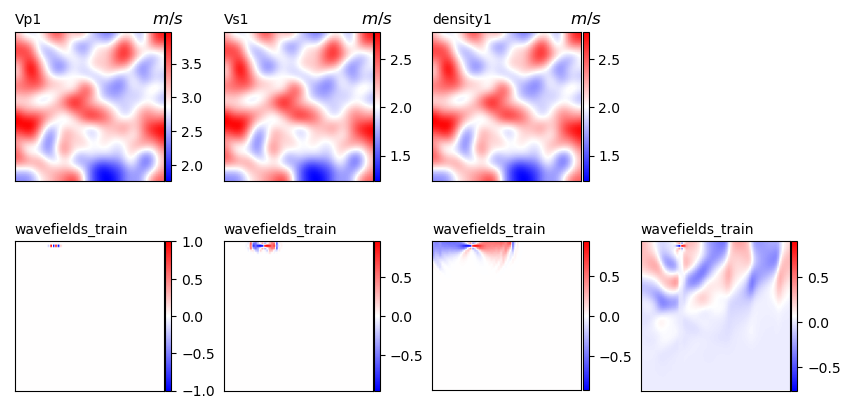

In [11]:
from Plotting_class import add_colorbar
model_index0 = 6
color = 'bwr'
fontsize_plt = 10

fig = plt.figure(figsize=(10, 5))
gs = fig.add_gridspec(2, 4)
ax = fig.add_subplot(gs[0, 0])
im = ax.imshow(Models_train_sub[model_index0,:,:,:,0].squeeze().detach(), cmap=color)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Vp1", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%", ctitle='$m/s$')

ax = fig.add_subplot(gs[0, 1])
im =ax.imshow(Models_train_sub[model_index0,:,:,:,1].squeeze().detach(), cmap=color)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Vs1", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%", ctitle='$m/s$')


ax = fig.add_subplot(gs[0, 2])
im =ax.imshow(Models_train_sub[model_index0,:,:,:,2].squeeze().detach(), cmap=color)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("density1", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%", ctitle='$m/s$')
##########################################################################################
##########################################################################################
##########################################################################################

ax = fig.add_subplot(gs[1, 0])
im = ax.imshow(vx_x_train_reshape_sub[model_index0,:,:,0,:].squeeze().detach(), cmap=color)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("wavefields_train", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%")

ax = fig.add_subplot(gs[1, 1])
im = ax.imshow(vx_x_train_reshape_sub[model_index0,:,:,10,:].squeeze().detach(), cmap=color)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("wavefields_train", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%")

ax = fig.add_subplot(gs[1, 2])
im = ax.imshow(vx_x_train_reshape_sub[model_index0,:,:,50,:].squeeze().detach(), cmap=color)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("wavefields_train", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%")

ax = fig.add_subplot(gs[1, 3])
im = ax.imshow(vx_x_train_reshape_sub[model_index0,:,:,-1,: ].squeeze().detach(), cmap=color)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("wavefields_train", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%")

plt.subplots_adjust(left=0.125,
                    bottom=0.1,
                    right=0.9,
                    top=0.9,
                    wspace=0.4,
                    hspace=0.1)

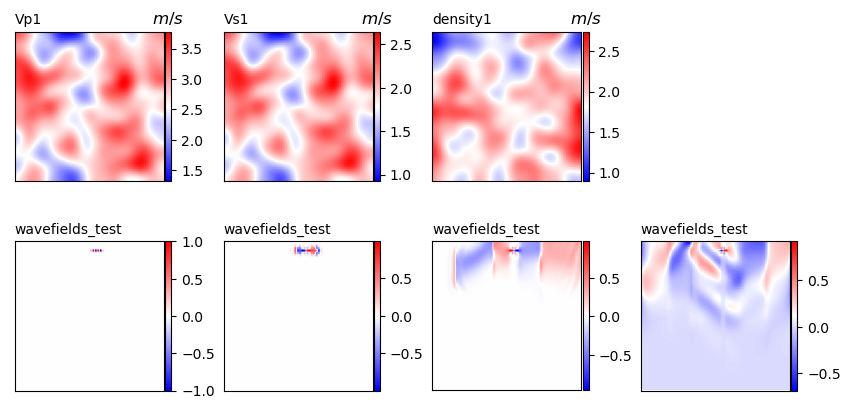

In [12]:
from Plotting_class import add_colorbar
model_index0 = -1
color = 'bwr'
fontsize_plt = 10

fig = plt.figure(figsize=(10, 5))
gs = fig.add_gridspec(2, 4)
ax = fig.add_subplot(gs[0, 0])
im = ax.imshow(Models_test_sub[model_index0,:,:,:,0].squeeze().detach(), cmap=color)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Vp1", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%", ctitle='$m/s$')

ax = fig.add_subplot(gs[0, 1])
im =ax.imshow(Models_test_sub[model_index0,:,:,:,1].squeeze().detach(), cmap=color)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Vs1", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%", ctitle='$m/s$')


ax = fig.add_subplot(gs[0, 2])
im =ax.imshow(Models_test_sub[model_index0,:,:,:,2].squeeze().detach(), cmap=color)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("density1", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%", ctitle='$m/s$')
##########################################################################################
##########################################################################################
##########################################################################################

ax = fig.add_subplot(gs[1, 0])
im = ax.imshow(vx_x_test_reshape_sub[model_index0,:,:,0,:].squeeze().detach(), cmap=color)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("wavefields_test", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%")

ax = fig.add_subplot(gs[1, 1])
im = ax.imshow(vx_x_test_reshape_sub[model_index0,:,:,10,:].squeeze().detach(), cmap=color)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("wavefields_test", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%")

ax = fig.add_subplot(gs[1, 2])
im = ax.imshow(vx_x_test_reshape_sub[model_index0,:,:,100,:].squeeze().detach(), cmap=color)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("wavefields_test", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%")

ax = fig.add_subplot(gs[1, 3])
im = ax.imshow(vx_x_test_reshape_sub[model_index0,:,:,-1,:].squeeze().detach(), cmap=color)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("wavefields_test", loc='left',fontsize=fontsize_plt)
cbar = add_colorbar(ax, im, ax.transAxes, width="4%")

plt.subplots_adjust(left=0.125,
                    bottom=0.1,
                    right=0.9,
                    top=0.9,
                    wspace=0.4,
                    hspace=0.1)

In [13]:
batch_size = 5
train_loader_sub = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(Models_train_sub, vx_x_train_reshape_sub), batch_size=batch_size, shuffle=True)
test_loader_sub = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(Models_test_sub, vx_x_test_reshape_sub), batch_size=batch_size, shuffle=True)
#test_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(Models_train[:ntrain,:,:,:], vx_x_train_reshape[:ntrain,:,:,:]), batch_size=batch_size, shuffle=True)

In [ ]:
# start the training
mode1 = 12
mode2 = 12
mode3 = 12
width = 16

device = torch.device('cuda')

model = FNO3d(mode1, mode2, mode3, width).cuda()
learning_rate = 1e-3
scheduler_step = 100
scheduler_gamma = 0.9
epochs = 1000
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=scheduler_step, gamma=scheduler_gamma)

training_loss_tensor = torch.zeros(epochs)
testing_loss_tensor  = torch.zeros(epochs)
testing_loss_tensor_high_resolution = torch.zeros(epochs)

myloss = LpLoss(size_average=False)
costFunc = torch.nn.MSELoss(reduction='sum')
for ep in range(epochs):
    model.train()
    t1 = default_timer()
    train_l2_step_training = 0
    test_l2_step_testing = 0
    test_l2_step_testing_high_resolution = 0
    loss = 0
    for C1, vx_x_label in train_loader_sub:
        vx_x_label = vx_x_label.to(device)    
        C1 = C1.repeat(1, 1, 1, time_prediction_number, 1).to(device)
        vx_x_input = (vx_x_label[:,:,:,:input_time].permute(0, 1, 2, 4, 3)).repeat(1, 1, 1, time_prediction_number, 1)
        im_train = model(C1, vx_x_input, dx=40, dy=40, dt=0.002)
        #print("this is the shape of the imtrain", im_train.shape, vx_x_label[:,:,:,input_time:].shape)
        vx_x_loss = myloss(im_train, vx_x_label[:,:,:,input_time:])
    
        loss = vx_x_loss
        train_l2_step_training += loss.item()
        optimizer.zero_grad()
        # backpropagation the residual
        loss.backward()
        optimizer.step()
    training_loss_tensor[ep] = train_l2_step_training


    loss = 0
    with torch.no_grad():
        for C1, vx_x_label in test_loader_sub:
            vx_x_label = vx_x_label.to(device)    
            C1 = C1.repeat(1, 1, 1, time_prediction_number, 1).to(device)
            vx_x_input = (vx_x_label[:,:,:,:input_time].permute(0, 1, 2, 4, 3)).repeat(1, 1, 1, time_prediction_number, 1)
            im_train = model(C1, vx_x_input, dx=40, dy=40, dt=0.002)
            #print("this is the shape of the imtrain", im_train.shape)
            vx_x_loss = vx_x_loss = myloss(im_train, vx_x_label[:,:,:,input_time:])
            loss = vx_x_loss
            test_l2_step_testing += loss.item()
        testing_loss_tensor[ep] = test_l2_step_testing
    loss = 0
    testing_loss_tensor_high_resolution[ep] = 0#test_l2_step_testing_high_resolution


    t2 = default_timer()
    print("epock",ep, \
          "time used/ep [{:.4e}]".format(t2 - t1), \
          "train loss [{:.8e}]".format(train_l2_step_training), \
          "test loss  [{:.8e}]".format(test_l2_step_testing))
    #scheduler.step()


    path = './'
    torch.save(model.state_dict(), path+'_model_add_velocity_0917_test4.pth')
    torch.save(training_loss_tensor, path+'_training_loss_tensor_0917_test4.pt')
    torch.save(testing_loss_tensor,  path+'_testing_loss_tensor_0917_test4.pt')

epock 0 time used/ep [1.7429e+02] train loss [3.28289451e+03] test loss  [1.98327241e+02]
epock 1 time used/ep [1.7342e+02] train loss [1.79236083e+03] test loss  [1.97979673e+02]
epock 2 time used/ep [1.7365e+02] train loss [1.79035334e+03] test loss  [1.97714475e+02]
epock 3 time used/ep [1.7367e+02] train loss [1.78929641e+03] test loss  [1.97758829e+02]
epock 4 time used/ep [1.7417e+02] train loss [1.78887191e+03] test loss  [1.97672912e+02]
epock 5 time used/ep [1.7256e+02] train loss [1.78872099e+03] test loss  [1.98003295e+02]
epock 6 time used/ep [1.7235e+02] train loss [1.78912702e+03] test loss  [1.97693631e+02]
epock 7 time used/ep [1.7265e+02] train loss [1.78874290e+03] test loss  [1.97649889e+02]
epock 8 time used/ep [1.7233e+02] train loss [1.78914013e+03] test loss  [1.98146874e+02]
epock 9 time used/ep [1.7250e+02] train loss [1.78940478e+03] test loss  [1.97745489e+02]
epock 10 time used/ep [1.7228e+02] train loss [1.78882445e+03] test loss  [1.97535298e+02]
epock 11 